In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [2]:
!wget https://www.openml.org/data/download/18631418/jungle_chess_2pcs_raw_endgame_complete.arff

--2025-04-10 13:03:52--  https://www.openml.org/data/download/18631418/jungle_chess_2pcs_raw_endgame_complete.arff
Resolving www.openml.org (www.openml.org)... 131.155.10.135
Connecting to www.openml.org (www.openml.org)|131.155.10.135|:443... connected.
HTTP request sent, awaiting response... 502 Proxy Error
2025-04-10 13:03:53 ERROR 502: Proxy Error.



In [5]:
!pip install openml

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 4.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 7.0 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11716 sha256=41c763398d3ebc656cd15237897284c786a37e3900cb771faa2b4e3b825a85ac
  Stored in directory: /root/.cache/pip/wheels/5d/2a/9c/3895d9617f8f49a0883ba686326d598e78a1c2f54fe3cae86d
Successfully built liac-arff


In [9]:
import openml as oml
dataset = oml.datasets.get_dataset(44090)

In [12]:
df, _, _, _ = dataset.get_data()

In [19]:
# !unzip census+income.zip

Archive:  census+income.zip
  inflating: adult.data              
  inflating: adult.names             
  inflating: adult.test              
  inflating: Index                   
  inflating: old.adult.names         


In [13]:
import pandas as pd

# df = pd.read_csv('adult.data', names = ['age','workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'])
print(len(df))
df

20634


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,2.1827,26,4.521429,0.921429,305.0,2.178571,40.05,-122.10,False
1,3.0755,32,4.623068,0.983353,3868.0,4.599287,32.77,-117.06,False
2,1.8235,40,4.701149,1.126437,928.0,3.555556,37.75,-122.16,False
3,1.4625,37,4.247845,1.105603,1673.0,3.605603,33.99,-118.28,False
4,1.9063,13,3.453125,0.984375,286.0,4.468750,33.97,-118.16,False
...,...,...,...,...,...,...,...,...,...
20629,4.3487,29,5.930712,1.026217,1554.0,2.910112,38.65,-121.84,True
20630,5.6790,20,6.401274,1.070064,457.0,2.910828,38.56,-122.05,True
20631,1.9327,10,5.789474,1.078947,898.0,3.938596,38.57,-121.92,True
20632,3.7500,38,5.275229,0.981651,259.0,2.376147,38.72,-121.90,True


In [16]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'price'],
      dtype='object')

In [18]:
import numpy as np
import torch

def concatenate_text(x):
    
    text = "".join([f"I have information about a district in California. ",
            f"Its median income is {x['MedInc']}. ",
            f"Its housing median age is {x['HouseAge']}. ",
            f"Its average rooms number is {x['AveRooms']}. ",
            f"Its average bedrooms number is {x['AveBedrms']}. ",
            f"Its total population is {x['Population']}. ",
            f"Its average number of people under the same roof is {x['AveOccup']}. ",
            f"Its latitude {x['Latitude']}. ",
            f"Its longitude {x['Longitude']}."])

    
    return text

concatenate_text(df.iloc[0])

'I have information about a district in California. Its median income is 2.1827. Its housing median age is 26. Its average rooms number is 4.521428571428571. Its average bedrooms number is 0.9214285714285714. Its total population is 305.0. Its average number of people under the same roof is 2.1785714285714284. Its latitude 40.05. Its longitude -122.1.'

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('price', axis =1),
                                                    df['price'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({True:1, False:0})
y_test = y_test.replace({True:1, False:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

<ipython-input-20-dd20caba4982>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({True:1, False:0})
<ipython-input-20-dd20caba4982>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({True:1, False:0})


In [21]:
X_train['text'].iloc[0]

'I have information about a district in California. Its median income is 5.5205. Its housing median age is 14.0. Its average rooms number is 7.225531914893617. Its average bedrooms number is 1.0340425531914894. Its total population is 1974.0. Its average number of people under the same roof is 2.8. Its latitude 38.8. Its longitude -121.25.'

In [22]:
len(X_train)

16507

In [23]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.3 MB/s eta 0:00:00


In [24]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
# id2label = {0: "NOT-DONATE", 1: "DONATE"}
# label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/16507 [00:00<?, ? examples/s]

Map:   0%|          | 0/4127 [00:00<?, ? examples/s]

Map:   0%|          | 0/16507 [00:00<?, ? examples/s]

Map:   0%|          | 0/4127 [00:00<?, ? examples/s]

In [25]:
tokenized_train_dataset[0].keys()

dict_keys(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [26]:
tokenized_train_dataset[0]['text']

'I have information about a district in California. Its median income is 5.5205. Its housing median age is 14.0. Its average rooms number is 7.225531914893617. Its average bedrooms number is 1.0340425531914894. Its total population is 1974.0. Its average number of people under the same roof is 2.8. Its latitude 38.8. Its longitude -121.25.'

In [27]:
tokenized_train_dataset[0]['label']

1

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.714100,0.693708,0.502907
2,0.694500,0.693015,0.538230
3,0.706800,0.696239,0.564863
4,0.697200,0.693844,0.537284
5,0.696500,0.698074,0.549172
6,0.692900,0.692295,0.558572
7,0.691400,0.692255,0.572277
8,0.693700,0.693067,0.591477
9,0.692500,0.692166,0.572763
10,0.692100,0.692498,0.572916


{'eval_loss': 0.6924983859062195, 'eval_roc_auc': 0.5729155511089818, 'eval_runtime': 15.3363, 'eval_samples_per_second': 269.101, 'eval_steps_per_second': 4.238, 'epoch': 10.0}
test f1 0.6633890527695837
test precision 0.5001235483073881
test recall 0.9849148418491485
test accuracy 0.5001235483073881
test roc_auc 0.5624306005692867



train f1 0.6654948289253158
train precision 0.5024381211036356
train recall 0.9852335996126845
train accuracy 0.5042709153692373
train roc_auc 0.5795077714844894


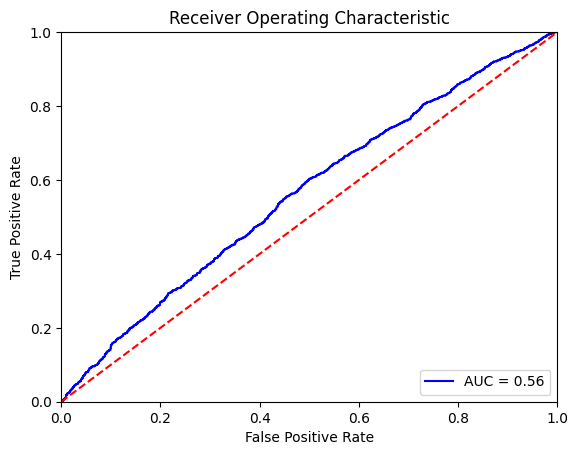

In [28]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.412500,0.401042,0.917421
2,0.315400,0.374337,0.937095
3,0.307800,0.290298,0.949875
4,0.307200,0.278675,0.953883
5,0.291200,0.270349,0.956535
6,0.274100,0.278061,0.957294
7,0.201300,0.270735,0.957819
8,0.239900,0.270324,0.958420
9,0.227000,0.267133,0.959029
10,0.206700,0.268048,0.959195


{'eval_loss': 0.26804813742637634, 'eval_roc_auc': 0.9591945438660767, 'eval_runtime': 15.4247, 'eval_samples_per_second': 267.558, 'eval_steps_per_second': 4.214, 'epoch': 10.0}
test f1 0.8939030244839175
test precision 0.8820464234959735
test recall 0.9060827250608272
test accuracy 0.8820464234959735
test roc_auc 0.9583655083655084



train f1 0.9188962207558488
train precision 0.9109181731684111
train recall 0.9270152505446623
train accuracy 0.9180953534863997
train roc_auc 0.9727219492488204


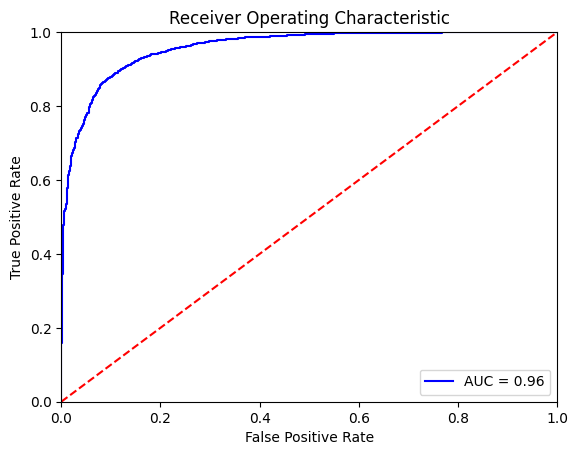

In [29]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()